<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# I.3 Tensão Tangencial Máxima. Círculo de Mohr.

## Problema 3 <a name="PI33"></a>

Considere as seguintes componentes cartesiandas do tensor de tensões num determinado sistema de coordenadas:

\begin{equation*}
\sigma_{ji} = [\sigma]^\top =
\begin{bmatrix}
180 & 0 & 240 \\
0 & -500 & 0 \\
240 & 0 & 320
\end{bmatrix} \textrm{kPa}
\end{equation*}

[a)](#A) Determine as tensões principais e as direções principais, via analítica/numérica.

[b)](#B) Determine as tensões principais e as direções principais pelo círculo de Mohr.

[c)](#C) Obtenha o tensor esférico e o tensor desviador. Descreva o significado físico de cada um destes tensores.

[d)](#D) Calcule a tensão de corte octaedral.

#### Nomenclatura

\begin{equation*}
\begin{aligned}
n_i &\quad \textrm{versor em notação indicial} \\
n_x &\quad \textrm{componente segundo o eixo dos $xx$ do versor $\vec{n}$} \\
n_y &\quad \textrm{componente segundo o eixo dos $yy$ do versor $\vec{n}$} \\
n_z &\quad \textrm{componente segundo o eixo dos $zz$ do versor $\vec{n}$} \\
tt0 &\quad \textrm{componentes cartesianas do tensor das tensões no referencial $S_0$} \\
[T_{01}] &\quad \textrm{matriz de transformação do sistema de coordenadas $S_0$ para $S_1$} \\
\sigma_{ij} &\quad \textrm{componentes cartesianas do tensor das tensões em notação indicial, no referencial $S_0$} \\
\sigma_{i'j'} &\quad \textrm{componentes cartesianas do tensor das tensões em notação indicial, no referencial $S_1$} \\
[^i\sigma] &\quad \textrm{matriz de tensão expressa no referencial $S_i$} \\
\sigma &\quad \textrm{valor próprio ou tensão principal} \\
\delta_{ij} &\quad \textrm{símbolo de Kronecker em notação indicial} \\
\end{aligned}
\end{equation*}

## Resolução

#### a) Determinação das tensões principais e as direções principais, via analítica/numérica.<a name="A"></a>

([enunciatum](#PI33))

A determinação das tensões principais (valores próprios da matriz das tensões, $\sigma_{ij}$) resulta da solução algébrica da equação:

\begin{equation*}
\det(\sigma_{ij}-\sigma \delta_{ij}) = 0
\end{equation*}

In [14]:
import numpy as np
from matplotlib import pyplot as plt
np.set_printoptions(precision=3)

def versor(n1,n2,n3): return np.array([n1,n2,n3])

def tensortens(sxx,sxy,sxz,syy,syz,szz):
    return np.array([[sxx,sxy,sxz],[sxy,syy,syz],[sxz,syz,szz]])

tt0 = tensortens(180,0,240,-500,0,320) # unidades; kPa

I1 = np.trace(tt0)
print('\n1º Invariante, I1:', '{:.1f}'.format(I1))
I2 = 0.5*(np.trace(tt0)**2 -np.trace(np.dot(tt0,tt0)))
print('2º Invariante, I2 :', '{:.1f}'.format(I2))
I3 = np.linalg.det(tt0)
print('3º Invariante, I3 :', '{:.1f}'.format(I3))

print('\n Resolução polinómio caraterístico : solução Numerica - Numpy : ............................')
valpropriosN = np.roots([1,-I1,I2,-I3])
print('\n Numpy : roots = ',valpropriosN)
valpropriosN = np.sort(valpropriosN)
sIII = round(valpropriosN[0])
sII = round(valpropriosN[1])
sI = round(valpropriosN[2])
print('\n Tensão principal (valor próprio) sI = ','{:.1f}'.format(sI),' kPa')
print('Tensão principal (valor próprio) sII = ','{:.1f}'.format(sII),' kPa')
print('Tensão principal (valor próprio) sIII = ','{:.1f}'.format(sIII),' kPa')


1º Invariante, I1: 0.0
2º Invariante, I2 : -250000.0
3º Invariante, I3 : 0.0

 Resolução polinómio caraterístico : solução Numerica - Numpy : ............................

 Numpy : roots =  [-500.  500.    0.]

 Tensão principal (valor próprio) sI =  500.0  kPa
Tensão principal (valor próprio) sII =  0.0  kPa
Tensão principal (valor próprio) sIII =  -500.0  kPa


As tensões principais são ordenadas por convenção por ordem descresente: $\sigma_\mathrm{I} \gt \sigma_\mathrm{II} \gt \sigma_\mathrm{III}$ ($500 \gt 0 \gt -500 $, unidades: kPa).

A determinação das direções principais associadas as tensões principais, resulta da solução algébrica de sistemas de equações na forma:

\begin{equation*}
(\sigma_{ij} - \sigma_\alpha\delta_{ij})\cdot n_j = 0 \quad \wedge \quad n_i \cdot n_i = 1
\quad (\alpha = \mathrm{I,II,III})
\end{equation*}

Nota: O sub-sistema de equações $(\sigma_{ij} - \sigma_\alpha\delta_{ij})n_j = 0$ não admite uma solução única, uma vez que a matriz de coeficientes $(\sigma_{ij} - \sigma_\alpha\delta_{ij})$ é singular (i.e., o seu determinante é nulo). Para ultrapassar esta indefinição, integra-se o conhecimento da norma do vetor que define a direção principal: $n_i \cdot n_i = 1$.

In [15]:
from sympy.solvers import solve
from sympy import symbols

nx,ny,nz = symbols('nx ny nz')

def eq1(nx,ny,nz,vp): return (tt0[0,0] - vp)*nx + tt0[0,1]*ny + tt0[0,2]*nz
def eq2(nx,ny,nz,vp): return tt0[1,0]*nx + (tt0[1,1] - vp)*ny + tt0[1,2]*nz
def eq3(nx,ny,nz,vp): return tt0[2,0]*nx + tt0[2,1]*ny + (tt0[2,2] - vp)*nz
def eq4(nx,ny,nz): return nx**2 + ny**2 + nz**2 - 1

# 1 valor proprio -------------------
print('-------------------------------------')
print('Vetor próprio associado a sI = ',sI,' kPa ')
print('-------------------------------------')
print('(i) sistema de equações:')
E11 = eq1(nx,ny,nz,sI); print(E11,' = 0')
E21 = eq2(nx,ny,nz,sI); print(E21,' = 0')
E31 = eq3(nx,ny,nz,sI); print(E31,' = 0')
E41 = eq4(nx,ny,nz); print(E41,' = 0')
VetProp1 = solve([E11,E21,E31,E41], [nx,ny,nz], dict=True)
l1 = float(VetProp1[1][nx])
m1 = float(VetProp1[1][ny])
n1 = float(VetProp1[1][nz])
versorI = versor(l1,m1,n1)
print('\n(ii) nI = ','{:.3f}'.format(l1),'i +','{:.3f}'.format(m1),'j +','{:.3f}'.format(n1),'k')

-------------------------------------
Vetor próprio associado a sI =  500  kPa 
-------------------------------------
(i) sistema de equações:
-320*nx + 240*nz  = 0
-1000*ny  = 0
240*nx - 180*nz  = 0
nx**2 + ny**2 + nz**2 - 1  = 0

(ii) nI =  0.600 i + 0.000 j + 0.800 k


Resultando o seguinte sistema de equações:

\begin{equation*}
\begin{cases}
-1.33(3)n_x + n_z  = 0 \\
n_y = 0 \\
n_x^2 + n_z^2  = 1 \\
\end{cases}
\Leftrightarrow
\begin{cases}
n_z  = 1.33(3)n_x  \\
n_y = 0 \\
(1+ 1.33(3)^2)n_x^2  = 1 \\
\end{cases}
\Leftrightarrow
\begin{cases}
n_z  = 1.33(3)n_x = \pm 0.8 \\
n_y = 0 \\
n_x = \pm \sqrt{0.36} = \pm 0.6\\
\end{cases}
\end{equation*}

escolhendo-se,

\begin{equation*}
\vec{n}_\mathrm{I} = 0.6 \vec{\imath} + 0.8 \vec{k}
\end{equation*}

In [16]:
print('-------------------------------------')
# 2 valor proprio -------------------
print('Vetor próprio associado a sII = ',sII,' KPa')
print('-------------------------------------')
print('(i) sistema de equações:')
E13 = eq1(nx,ny,nz,sII); print(E13,' = 0')
E23 = eq2(nx,ny,nz,sII); print(E23,' = 0')
E33 = eq3(nx,ny,nz,sII); print(E33,' = 0')
E43 = eq4(nx,ny,nz); print(E43,' = 0')
VetProp2 = solve([E13,E23,E33,E43], [nx,ny,nz], dict=True)
l2 = float(VetProp2[0][nx])
m2 = float(VetProp2[0][ny])
n2 = float(VetProp2[0][nz])
versorII = versor(l2,m2,n2)
print('\n(ii) nII = (','{:.3f}'.format(l2),') i + (','{:.3f}'.format(m2),') j + (','{:.3f}'.format(n2),') k')

-------------------------------------
Vetor próprio associado a sII =  0  KPa
-------------------------------------
(i) sistema de equações:
180*nx + 240*nz  = 0
-500*ny  = 0
240*nx + 320*nz  = 0
nx**2 + ny**2 + nz**2 - 1  = 0

(ii) nII = ( -0.800 ) i + ( 0.000 ) j + ( 0.600 ) k


Resultando,

\begin{equation*}
\vec{n}_\mathrm{II} = -0.8 \vec{\imath} + 0.6 \vec{k}
\end{equation*}

In [4]:
# 3 valor proprio -------------------
print('-------------------------------------')
print('Vetor próprio associado a sIII = ',sIII,' kPa')
print('-------------------------------------')
print('(i) sistema de equações:')
E13 = eq1(nx,ny,nz,sIII); print(E13,' = 0')
E23 = eq2(nx,ny,nz,sIII); print(E23,' = 0')
E33 = eq3(nx,ny,nz,sIII); print(E33,' = 0')
E43 = eq4(nx,ny,nz); print(E43,' = 0')
VetProp3 = solve([E13,E23,E33,E43], [nx,ny,nz], dict=True)
l3 = float(VetProp3[1][nx])
m3 = float(VetProp3[1][ny])
n3 = float(VetProp3[1][nz])
versorIII = versor(l3,m3,n3)
print('\n(ii) nIII = (','{:.3f}'.format(l3),') i + (','{:.3f}'.format(m3),') j + (','{:.3f}'.format(n3),') k')

-------------------------------------
Vetor próprio associado a sIII =  -500  kPa
-------------------------------------
(i) sistema de equações:
680*nx + 240*nz  = 0
0  = 0
240*nx + 820*nz  = 0
nx**2 + ny**2 + nz**2 - 1  = 0

(ii) nIII = ( 0.000 ) i + ( 1.000 ) j + ( 0.000 ) k


Resultando,

\begin{equation*}
\vec{n}_\mathrm{III} \equiv \vec{\jmath}
\end{equation*}

As direções principais devem formar entre si um sistema de coordenadas ortonormado e direto:

\begin{equation*}
n_i \cdot n_j = \delta_{ij} \quad (i.j = \mathrm{I,II,III})
\end{equation*}

In [5]:
print('\n Sistema de coordenadas ortonormado e direto : verificação\n ')
print('dot(vp1,vp1) = ','{:.1f}'.format(np.dot(versorI,versorI)))
print('dot(vp2,vp2) = ', '{:.1f}'.format(np.dot(versorII,versorII)))
print('dot(vp3,vp3) = ', '{:.1f}'.format(np.dot(versorIII,versorIII)))
print('dot(vp1,vp2) = ', np.dot(versorI,versorII))
print('dot(vp2,vp3) = ', np.dot(versorII,versorIII))
print('dot(vp1,vp3) = ', np.dot(versorI,versorIII))


 Sistema de coordenadas ortonormado e direto : verificação
 
dot(vp1,vp1) =  1.0
dot(vp2,vp2) =  1.0
dot(vp3,vp3) =  1.0
dot(vp1,vp2) =  0.0
dot(vp2,vp3) =  0.0
dot(vp1,vp3) =  0.0


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au03/Au03_P003_i1.jpg" width="400" height="270">

\begin{equation*}
\begin{aligned}
\bullet~&~\sigma_\mathrm{I} \quad \mapsto \quad
\vec{n}_\mathrm{I} \\
\bullet~&~\sigma_\mathrm{II} \quad \mapsto \quad
\vec{n}_\mathrm{II} \\
\bullet~&~\sigma_\mathrm{III} \quad \mapsto \quad
\vec{n}_\mathrm{III} \\
\end{aligned}\quad
\Leftrightarrow\quad
\begin{cases}
\vec{n}_\mathrm{I} \equiv \vec{\imath}_\mathrm{P} = 0.6~\vec{\imath} + 0.8~\vec{k} \\
\vec{n}_\mathrm{II} \equiv \vec{k}_\mathrm{P} = -0.8~\vec{\imath}  + 0.6~\vec{k} \\
\vec{n}_\mathrm{III} \equiv \vec{\jmath}_\mathrm{P} = \vec{\jmath}\\
\end{cases}
\end{equation*}

\begin{equation*}
[T_{\mathrm{0P}}(-\theta)] =
\begin{bmatrix}
l_1 & m_1 & n_1 \\
l_2 & m_2 & n_2 \\
l_3 & m_3 & n_3
\end{bmatrix} =
\begin{bmatrix}
\vec{\imath}_\mathrm{P} \cdot \vec{\imath} &
\vec{\imath}_\mathrm{P} \cdot \vec{\jmath} &
\vec{\imath}_\mathrm{P} \cdot \vec{k} \\
\vec{\jmath}_\mathrm{P} \cdot \vec{\imath} &
\vec{\jmath}_\mathrm{P} \cdot \vec{\jmath} &
\vec{\jmath}_\mathrm{P} \cdot \vec{k} \\
\vec{k}_\mathrm{P} \cdot \vec{\imath} &
\vec{k}_\mathrm{P} \cdot \vec{\jmath} &
\vec{k}_\mathrm{P} \cdot \vec{k}
\end{bmatrix} =
\begin{bmatrix}
\cos\theta & 0 & \sin\theta \\
0 & 1 & 0 \\
-\sin\theta & 0 & \cos\theta \\
\end{bmatrix} =
\begin{bmatrix}
0.6 & 0. &  0.8    \\
0. & 1. & 0.  \\
-0.8 & 0.  & 0.6 \\
\end{bmatrix}
\end{equation*}

A transformação para as direções principais de tensão:

\begin{equation*}
\begin{aligned}
\underline{\underline{\sigma}}_P&=\underline{\underline{T}}_{0P}\,\underline{\underline{\sigma}}_0~
\underline{\underline{T}}_{0P}^T
\end{aligned}
\end{equation*}

In [6]:
np.set_printoptions(precision=3,suppress=True)

xP = versorI
yP = versorIII
zP = versorII

MatrTrans = np.array([xP,yP,zP])
print('MatrTrans = \n',MatrTrans)
sprinc = np.dot(MatrTrans,np.dot( tt0 ,np.transpose(MatrTrans) ))
print('Matriz das tensões no refencial principal = \n',sprinc)

MatrTrans = 
 [[ 0.6  0.   0.8]
 [ 0.   1.   0. ]
 [-0.8  0.   0.6]]
Matriz das tensões no refencial principal = 
 [[ 500.    0.   -0.]
 [   0. -500.    0.]
 [  -0.    0.    0.]]


De onde a matriz de tensão no referencial principal vem:

\begin{equation*}
^P\underline{\underline{\sigma}} =
\begin{bmatrix}
\sigma_\mathrm{I} & 0 & 0 \\
0 & \sigma_\mathrm{III} & 0 \\
0 & 0 & \sigma_\mathrm{II} \\
\end{bmatrix} =
\begin{bmatrix}
500.  & 0 & 0 \\
0 & -500.  & 0 \\
0 & 0 & 0. \\
\end{bmatrix}~\textrm{MPa}
\end{equation*}

In [7]:
np.set_printoptions(precision=3)
print('\n Matriz de transformação de S0 para SI (ref. principal): ')

print('\n Àngulo entre xP e x: ')
print('\n theta_P = ','{:.2f}'.format(np.rad2deg(np.arccos(l1))), ' Deg')

print('Versor principal xP: \n')
xPx = np.rad2deg(np.arccos(float(xP[0])))
print('xP.x = ','{:.2f}'.format(xPx),'º')
xPy = np.rad2deg(np.arccos(float(xP[1])))
print('xP.y = ','{:.2f}'.format(xPy),'º')
xPz = np.rad2deg(np.arccos(float(xP[2])))
print('xP.z = ','{:.2f}'.format(xPz),'º')

print('\nVersor principal yP: \n')
yPx = np.rad2deg(np.arccos(float(yP[0])))
print('yP.x = ','{:.2f}'.format(yPx),'º')
yPy = np.rad2deg(np.arccos(float(yP[1])))
print('yP.y = ','{:.2f}'.format(yPy),'º')
yPz = np.rad2deg(np.arccos(float(yP[2])))
print('yP.z = ','{:.2f}'.format(yPz),'º')

print('\nVersos principal zP: \n')
zPx = np.rad2deg(np.arccos(float(zP[0])))
print('zP.x = ','{:.2f}'.format(zPx),'º')
zPy = np.rad2deg(np.arccos(float(zP[1])))
print('zP.y = ','{:.2f}'.format(zPy),'º')
zPz = np.rad2deg(np.arccos(float(zP[2])))
print('zP.z = ','{:.2f}'.format(zPz),'º')

mT = np.concatenate((xP, yP, zP))
mT = mT.reshape(3,3)
print('\n [T] = \n', mT)

print('\n[T][T]^T = I :\n',np.dot(np.transpose(mT),mT))

print('\n det(T) = ','{:.2f}'.format(np.linalg.det(mT)))


 Matriz de transformação de S0 para SI (ref. principal): 

 Àngulo entre xP e x: 

 theta_P =  53.13  Deg
Versor principal xP: 

xP.x =  53.13 º
xP.y =  90.00 º
xP.z =  36.87 º

Versor principal yP: 

yP.x =  90.00 º
yP.y =  0.00 º
yP.z =  90.00 º

Versos principal zP: 

zP.x =  143.13 º
zP.y =  90.00 º
zP.z =  53.13 º

 [T] = 
 [[ 0.6  0.   0.8]
 [ 0.   1.   0. ]
 [-0.8  0.   0.6]]

[T][T]^T = I :
 [[ 1.  0. -0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]

 det(T) =  1.00


##### Transformação do tensor das tensões

As componentes do tensor das tensões num referencial arbitrário $S_1$ podem ser obtidas em relação ao sistema de
coordenadas de referência $S_0$, atravez das seguintes leis de tranformação:

\begin{equation*}
\begin{aligned}
[\sigma]_1 &= [T_{01}]\,[\sigma]_0\,[T_{01}]^{\mathrm{T}}
\end{aligned}
\end{equation*}

cujo desenvolvimento algébrico conduz a,

\begin{equation*}
\begin{aligned}
\sigma_{x'x'} &= \frac{\sigma_{xx} + \sigma_{yy} }{2} + \frac{\sigma_{xx} - \sigma_{yy} }{2} \cos2\theta -
\tau_{xy}\sin2\theta \\
\sigma_{y'y'} &= \frac{\sigma_{xx} + \sigma_{yy} }{2} - \frac{\sigma_{xx} - \sigma_{yy} }{2} \cos2\theta -
\tau_{xy}\sin2\theta \\
\tau_{x'y'} &= \frac{\sigma_{yy} - \sigma_{xx} }{2} \sin2\theta + \tau_{xy}\cos2\theta \\
\end{aligned}
\end{equation*}

-----------------
PLANO x-z:
-----------------
Tensões (normais) principais: -------------------------------------------
angPrincipal 1 = -36.87  Deg
tens xx plano principal [1] (MPa) = 0.0  kPa
tens zz plano principal [1] (MPa) = 500.0  kPa
tens xz plano principal [1] (MPa) = 0.0  kPa

angPrincipal 2 = 53.13  Deg
tens xx plano principal [2] (MPa) = 500.0  kPa
tens zz plano principal [2] (MPa) = 0.0  kPa
tens xz plano principal [2] (MPa) = 0.0  kPa

Tensões de corte maximas/mínima: -------------------------------------------
Ângulo tensão corte max (Deg) = 8.13
tens xx - plano  tensão de corte max (MPa) = 250.00
tens yy - plano  tensão de corte max (MPa) = 250.00
tens xy - plano  tensão de corte max (MPa) = 250.00
Ângulo tensão corte min (Deg) = 98.13
tens xx - plano  tensão de corte min (MPa) = 250.00
tens yy - plano  tensão de corte min (MPa) = 250.00
tens xy - plano  tensão de corte min (MPa) = -250.00


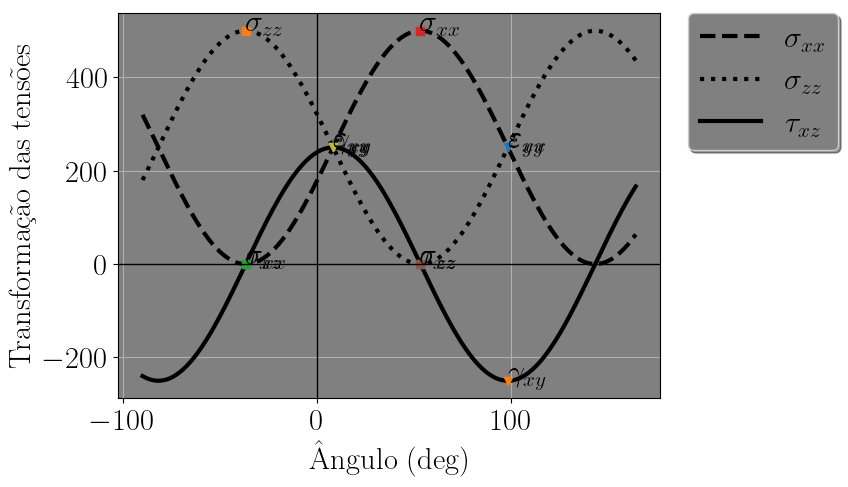

In [8]:
def S11t(S11,S22,S12,t):
    return (S11+S22)/2 + (S11-S22)/2*np.cos(2*t) + S12*np.sin(2*t)

def S22t(S11,S22,S12,t):
    return (S11+S22)/2 - (S11-S22)/2*np.cos(2*t) - S12*np.sin(2*t)

def S12t(S11,S22,S12,t):
    return (S22-S11)/2*np.sin(2*t) + S12*np.cos(2*t)

def angPrincipal(S11,S22,S12):
    return np.arctan(2*S12/(S11-S22))/2

def angS(s11,s22,s12): return -np.arctan((s11-s22)/(2*s12))

print('-----------------')
print('PLANO x-z:')
print('-----------------')
sxx = tt0[0,0] # neste caso: x = y; y = z
txz = tt0[0,2]
szz = tt0[2,2]

angt = np.arange(-90,165,1)
tsxx = S11t(sxx,szz,txz,np.deg2rad(angt))
tszz = S22t(sxx,szz,txz,np.deg2rad(angt))
ttxz = S12t(sxx,szz,txz,np.deg2rad(angt))

print('Tensões (normais) principais: -------------------------------------------')
aprinc = np.rad2deg(angPrincipal(sxx,szz,txz))
print('angPrincipal 1 =','{:.2f}'.format(aprinc),' Deg')
tP1sxx = S11t(sxx,szz,txz,np.deg2rad(aprinc))
tP1szz = S22t(sxx,szz,txz,np.deg2rad(aprinc))
tP1txz = S12t(sxx,szz,txz,np.deg2rad(aprinc))
print('tens xx plano principal [1] (MPa) =','{:.1f}'.format(tP1sxx),' kPa')
print('tens zz plano principal [1] (MPa) =','{:.1f}'.format(tP1szz),' kPa')
print('tens xz plano principal [1] (MPa) =','{:.1f}'.format(tP1txz),' kPa')

aprinc2 = aprinc + 90
print('\nangPrincipal 2 =','{:.2f}'.format(aprinc2),' Deg')
tP2sxx = S11t(sxx,szz,txz,np.deg2rad(aprinc2))
tP2szz = S22t(sxx,szz,txz,np.deg2rad(aprinc2))
tP2txz = S12t(sxx,szz,txz,np.deg2rad(aprinc2))
print('tens xx plano principal [2] (MPa) =','{:.1f}'.format(tP2sxx),' kPa')
print('tens zz plano principal [2] (MPa) =','{:.1f}'.format(tP2szz),' kPa')
print('tens xz plano principal [2] (MPa) =','{:.1f}'.format(np.abs(tP2txz)),' kPa')

print('\nTensões de corte maximas/mínima: -------------------------------------------')
aS1 = angS(sxx,szz,txz)/2 # ângulo no espaço físico, radianos
print('Ângulo tensão corte max (Deg) =','{:.2f}'.format(np.rad2deg(aS1)))
tcortexxMa = S11t(sxx,szz,txz,aS1)
tcorteyyMa = S22t(sxx,szz,txz,aS1)
tcortexyMa = S12t(sxx,szz,txz,aS1)
print('tens xx - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcortexxMa))
print('tens yy - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcorteyyMa))
print('tens xy - plano  tensão de corte max (MPa) =','{:.2f}'.format(tcortexyMa))

aS2 = aS1 + np.pi/2
print('Ângulo tensão corte min (Deg) =','{:.2f}'.format(np.rad2deg(aS2)))
tcortexxMb = S11t(sxx,szz,txz,aS2)
tcorteyyMb = S22t(sxx,szz,txz,aS2)
tcortexyMb = S12t(sxx,szz,txz,aS2)
print('tens xx - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexxMb))
print('tens yy - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcorteyyMb))
print('tens xy - plano  tensão de corte min (MPa) =','{:.2f}'.format(tcortexyMb))

# use LaTeX fonts in the plot
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size = 22)
plt.rcParams['axes.facecolor']='gray'
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(angt, tsxx, 'k--', label=r'$\sigma_{xx}$', linewidth=3)
ax.plot(angt, tszz, 'k:', label=r'$\sigma_{zz}$', linewidth=3)
ax.plot(angt, ttxz, 'k', label=r'$\tau_{xz}$', linewidth=3)
# points: principal stresses
ax.plot(aprinc, tP1sxx, 's'), ax.text(aprinc, tP1sxx,r'$\sigma_{xx}$')
ax.plot(aprinc, tP1szz, 's'), ax.text(aprinc, tP1szz,r'$\sigma_{zz}$')
ax.plot(aprinc, tP1txz, 's'), ax.text(aprinc, tP1txz,r'$\tau_{xz}$')
ax.plot(aprinc2, tP2sxx, 's'), ax.text(aprinc2, tP2sxx,r'$\sigma_{xx}$')
ax.plot(aprinc2, tP2szz, 's'), ax.text(aprinc2, tP2szz,r'$\sigma_{zz}$')
ax.plot(aprinc2, tP2txz, 's'), ax.text(aprinc2, tP2txz,r'$\tau_{xz}$')
# points: critical shear stresses
ax.plot(np.rad2deg(aS1), tcortexxMa, 'v')
ax.text(np.rad2deg(aS1), tcortexxMa,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aS1), tcorteyyMa, 'v')
ax.text(np.rad2deg(aS1), tcorteyyMa,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aS1), tcortexyMa, 'v')
ax.text(np.rad2deg(aS1), tcortexyMa,r'$\gamma_{xy}$')
ax.plot(np.rad2deg(aS2), tcortexxMb, 'v')
ax.text(np.rad2deg(aS2), tcortexxMb,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aS2), tcorteyyMb, 'v')
ax.text(np.rad2deg(aS2), tcorteyyMb,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aS2), tcortexyMb, 'v')
ax.text(np.rad2deg(aS2), tcortexyMb,r'$\gamma_{xy}$')

ax.set(xlabel='Ângulo (deg)', ylabel='Transformação das tensões')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.,
                   shadow=True, fontsize=22)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

> b) Determinação das tensões principais e as direções principais pelo
círculo de Mohr.<a name="B"></a>

([enunciatum](#PI33))

Pela análise prévia das componentes cartesianas da matriz do tensor das tensões pode concluir-se que a direção $\vec{\jmath}$ é uma
direção principal de tensão pois $\tau_{yx} = \tau_{yz} = 0$ e $\sigma_{yy} \ne 0$.  O valor de $\sigma_{yy}$ é uma
tensão principal de tensão e raiz do polinómio ou equação caraterística. De facto pode mostrar-se pelo desenvolvimento
algebrico que: $\sigma_{yy} \equiv \sigma_{\mathrm{III}}$ = -500 MPa.

A implementação gráfica do método da circunferência de Mohr implica os seguintes passos, assumindo o plano de
representação $x-z$:

1. No plano $\sigma-\tau$ (abcissa, ordenada) marcar o ponto correspondente ao
estado $(\sigma_{xx}, +\tau_{xz})$ que atua na faceta $A$ (com normal segundo a direção do eixo dos $xx$). De notar que,
a componente de corte aponta para um sentido horário, logo, por convensão, a tensão de corte representa-se positivamente
no círculo de Mohr.

2. No plano $\sigma-\tau$ indicar o ponto correspondente ao
estado $(\sigma_{zz}, -\tau_{xz})$ que atua na faceta $B$ (normal ao eixo dos $zz$). De notar que, a componente de corte
aponta no sentido positivo de $xx$ pelo que, por convensão, a tensão de corte é representada negativa na circunferência
de Mohr.

3. Traçar o segmento de reta entre os dois pontos $A$ e $B$.

4. Desenhar o círculo com diâmetro igual ao comprimento do segmento de reta $\overline{AB}$.

5. Cálcular a coordenada da tensão normal correspondente ao centro do círculo, $C$:

\begin{equation*}
C \equiv \sigma_\mathrm{médio} = \frac{\sigma_{xx} + \sigma_{zz}}{2}
\end{equation*}

6. Cálcular o raio do círculo, $R$:

\begin{equation*}
R \equiv |\tau_\mathrm{max}| = \sqrt{\left(\frac{\sigma_{xx}-\sigma_{zz}}{2}\right)^2 + \tau_{xz}^2}
\end{equation*}

7. Determinar as tensões principais, $\sigma_{P1}$ e $\sigma_{P2}$:

\begin{equation*}
\sigma_\mathrm{P1,P2} \equiv \sigma_\mathrm{min,max} = C \pm R = \frac{\sigma_{xx} + \sigma_{zz}}{2} \pm
\sqrt{\left(\frac{\sigma_{xx}-\sigma_{zz}}{2}\right)^2 + \tau_{xz}^2}
\end{equation*}

8. Calcular as direções principais de tensão, $\theta_{P1}$ e $\theta_{P2}$:

\begin{equation*}
\begin{aligned}
2\theta_{P1} &= \tan^{-1} \left(\frac{2\tau_{xz}}{\sigma_{xx}-\sigma_{zz}}\right) \\
2\theta_{P2} &= 2\theta_{P1} + 180^\circ\\
\end{aligned}
\end{equation*}

--------------------------
Circulo de Mohr
--------------------------

PLANO x-z:

Ponto A ( 180.0 , 240.0 )
Ponto B ( 320.0 , -240.0 )
  Tensão normal mínima:  0.0
  Tensão normal máxima:  500.0
  Tensão normal média :  250.0
Tensão de corte mínima:  -250.0
Tensão de corte máxima:  250.0


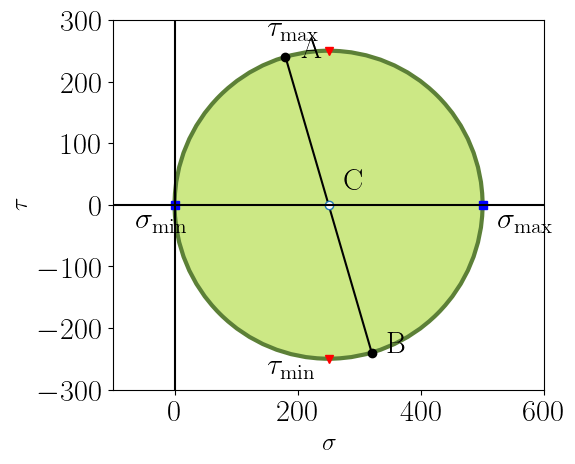

In [9]:
print('--------------------------')
print('Circulo de Mohr')
print('--------------------------')

def mohr(S,limits):
    """Plot Mohr circle for a 2D tensor"""
    S11 = S[0][0]
    S12 = S[0][1]
    S22 = S[1][1]
    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)
    Smin = center[0] - radius
    Smax = center[0] + radius

    print('Ponto A (','{:.1f}'.format(S11),',','{:.1f}'.format(S12),')')
    print('Ponto B (','{:.1f}'.format(S22),',','{:.1f}'.format(-S12),')')

    print("  Tensão normal mínima: ", np.round(Smin,6))
    print("  Tensão normal máxima: ", np.round(Smax, 6))
    print("  Tensão normal média : ", np.round(center[0], 6))
    print("Tensão de corte mínima: ", np.round(-radius, 6))
    print("Tensão de corte máxima: ", np.round(radius, 6))

    plt.rcParams['axes.facecolor']='white'
    circ = plt.Circle((center[0],0), radius, facecolor='#cce885', lw=3,
    edgecolor='#5c8037')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Smin - .3*radius, Smax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([S11, S22], [S12, -S12], 'ko')
    plt.plot([S11, S22], [S12, -S12], 'k')
    plt.plot(Smin, 0, 'bs')
    plt.plot(Smax, 0, 'bs')
    plt.plot(center[0], radius, 'rv')
    plt.plot(center[0], -radius, 'rv')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    plt.text(S22 + desv, -S12 , 'B')
    plt.text(S11 + desv, S12 , 'A')
    plt.text(Smin - 0.25*radius, -0.15*radius, r'$\sigma_\mathrm{min}$')
    plt.text(Smax + desv, -0.15*radius, r'$\sigma_\mathrm{max}$')
    plt.text(center[0]-4*desv, 1.1*radius, r'$\tau_\mathrm{max}$')
    plt.text(center[0]-4*desv, -1.1*radius, r'$\tau_\mathrm{min}$')
    plt.xlabel(r"$\sigma$", size=18)
    plt.ylabel(r"$\tau$", size=18)
    plt.xlim(limits[0,0],limits[0,1])
    plt.ylim(limits[1,0],limits[1,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

S = tt0

axislim = np.array([[-100,600],[-300,300]])
print('\nPLANO x-z:\n')
S11 = S[0,0]
S12 = S[0,2]
S22 = S[2,2]
mohr(np.array([[S11, S12],[S12, S22]]),axislim)

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au03/Au03_P003_i2.jpg"
width="350" height="270">

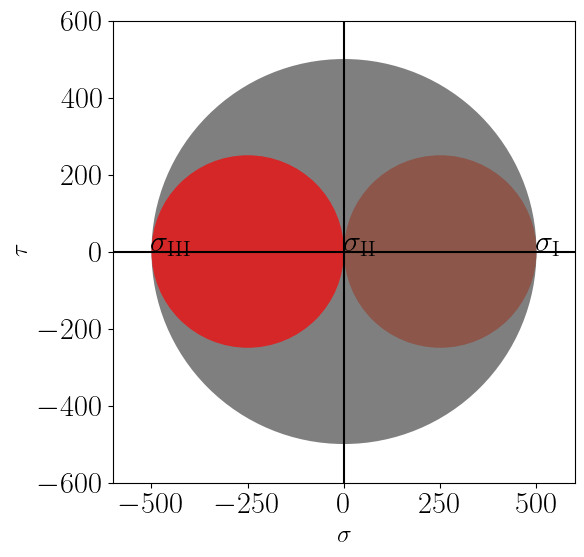

In [10]:
def circleradius(S):
    S11 = S[0,0]
    S12 = S[0,1]
    S22 = S[1,1]

    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)

    return center, radius

limits = np.array([[-600,600],[-600,600]])

sigI = sI
sigII = sII
sigIII = sIII

s11 = sigI; s22 = sigIII; s12 = 0
S = np.array([[s11, s12],[s12, s22]])
center1, radius1  = circleradius(S)

s11 = sigI; s22 = sigII; s12 = 0
S = np.array([[s11, s12],[s12, s22]])
center2, radius2  = circleradius(S)

s11 = sigII; s22 = sigIII; s12 = 0
S = np.array([[s11, s12],[s12, s22]])
center3, radius3  = circleradius(S)

plt.rcParams['axes.facecolor']='white'
fig, ax = plt.subplots(figsize=(6, 6))
circ1 = plt.Circle((center1[0],0), radius1, facecolor='#7f7f7f')
circ2 = plt.Circle((center2[0],0), radius2, facecolor='#8c564b')
circ3 = plt.Circle((center3[0],0), radius3, facecolor='#d62728')

plt.axis('image'); ax = plt.gca()

plt.gcf().gca().add_artist(circ1)
plt.gcf().gca().add_artist(circ2)
plt.gcf().gca().add_artist(circ3)

plt.xlabel(r"$\sigma$", size=18)
plt.ylabel(r"$\tau$", size=18)

plt.text(1.*sigI, 0, r'$\sigma_\mathrm{I}$')
plt.text(1.*sigII, 0, r'$\sigma_\mathrm{II}$')
plt.text(1.*sigIII, 0, r'$\sigma_\mathrm{III}$')

plt.xlim(limits[0,0],limits[0,1])
plt.ylim(limits[1,0],limits[1,1])

ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')

plt.show()

No plano de análise $x-z$ as tensões principais vêm $\sigma_\mathrm{I} = 500$ MPa e $\sigma_\mathrm{II} = 500$ MPa,
sendo as direções principais, no espaço das tensões da circunferência de Mohr, dadas por

\begin{equation*}
\begin{aligned}
2\theta_{P1} &= -73.74^\circ \quad | \quad
2\theta_{P2} &= 106.26^\circ\\
\end{aligned}
\end{equation*}

que correspondem ao espaço físico ao valores:

\begin{equation*}
\begin{aligned}
\theta_{P1} &= -36.87^\circ \quad | \quad
\theta_{P2} &= 53.13^\circ\\
\end{aligned}
\end{equation*}

In [11]:
sxx = tt0[0,0]
szz = tt0[2,2]
sxz = tt0[0,2]

def angP(s11,s22,s12): return np.arctan((2*s12)/(s11-s22))

aP1 = angP(sxx,szz,sxz)
aP2 = aP1 + np.pi

print('angulos das direções principais')
print('\nNo espaço das tensões:')
print('angPI:  ','{:.3f}'.format(np.rad2deg(aP1)),' deg | ','{:.3f}'.format(aP1),' radians')
print('angPII: ','{:.3f}'.format(np.rad2deg(aP2)),' deg | ','{:.3f}'.format(aP2),' radians')

aPI = aP1/2
aPII = aP2/2

print('\nNo espaço fisico:')
print('angPI:  ','{:.3f}'.format(np.rad2deg(aPI)),' deg | ','{:.3f}'.format(aPI),' radians')
print('angPII: ','{:.3f}'.format(np.rad2deg(aPII)),' deg | ','{:.3f}'.format(aPII),' radians')

print('\nVetors principais:')
nI = versor(np.cos(aPII),round(np.cos(np.pi/2)),np.cos(np.pi/2-aPII))
print(nI)
nII = versor(np.cos(np.pi/2+aPII),round(np.cos(np.pi/2)),np.cos(aPII))
print(nII)

angulos das direções principais

No espaço das tensões:
angPI:   -73.740  deg |  -1.287  radians
angPII:  106.260  deg |  1.855  radians

No espaço fisico:
angPI:   -36.870  deg |  -0.644  radians
angPII:  53.130  deg |  0.927  radians

Vetors principais:
[0.6 0.  0.8]
[-0.8  0.   0.6]


### c) Obtenha o tensor esférico e o tensor desviador. Descreva o significado físico de cada um destes tensores.<a name="C"></a>
([enunciatum](#PI33))

\begin{equation*}
[\sigma] = [\sigma]_M + [\sigma]_D
\end{equation*}

em que $[\sigma]_M$ é o tensor esférico ou hidrostático defenido por:

\begin{equation*}
[\sigma]_M = \begin{bmatrix}
\sigma_m & 0 & 0 \\
0 & \sigma_m & 0\\
0 & 0 & \sigma_m \\
\end{bmatrix}
\end{equation*}

onde $\sigma_m = \sigma_{ii}/3 = (\sigma_{11} + \sigma_{22} +\sigma_{33})/3$

e $[\sigma]_D$ é o tensor desviador dado por:

\begin{equation*}
[\sigma]_D = \begin{bmatrix}
\sigma_{11}-\sigma_{ii}/3 & \sigma_{12} & \sigma_{13} \\
\sigma_{21} & \sigma_{22}-\sigma_{ii}/3 & \sigma_{23}\\
\sigma_{31} & \sigma_{32} & \sigma_{33}-\sigma_{ii}/3 \\
\end{bmatrix}
\end{equation*}

In [12]:
def sij(sxx,sxy,sxz,syy,syz,szz):
    return np.array([[sxx,sxy,sxz],[sxy,syy,syz],[sxz,syz,szz]])

sij_xyz = sij(180,0,240,-500,0,320)
print('sij_xyz = ',sij_xyz)

s11 = sij_xyz[0,0]
s22 = sij_xyz[1,1]
s33 = sij_xyz[2,2]

sigma_m = (s11 + s22 + s33)/3
print('sigma_m = sigma_ii /3 = ',sigma_m)
print('tensor esférico é nulo')
print('tensor desviador é igual ao tensor das tensões')

sij_xyz =  [[ 180    0  240]
 [   0 -500    0]
 [ 240    0  320]]
sigma_m = sigma_ii /3 =  0.0
tensor esférico é nulo
tensor desviador é igual ao tensor das tensões


### d) Obtenha tensão de corte octaedral.<a name="D"></a>
([enunciatum](#PI33))

A tensão de corte octaedral é dada por:

\begin{equation*}
\sigma_{\mathrm{oct}} = \frac{1}{3}
\sqrt{(\sigma_{\mathrm{I}}-\sigma_{\mathrm{II}})^2+
(\sigma_{\mathrm{II}}-\sigma_{\mathrm{III}})^2+
(\sigma_{\mathrm{I}}-\sigma_{\mathrm{III}})^2}
\end{equation*}

In [13]:
def toct(sI,sII,sIII):
    return (np.sqrt((sI-sII)**2 + (sII-sIII)**2 + (sI-sIII)**2))/3

toct1 = toct(sI,sII,sIII)
print('toct = ','{:.2f}'.format(toct1),' MPa')

toct =  408.25  MPa


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

